# EN vs ZH Model Comparison — Typographic Attacks

**Focus:** English and Chinese CLIP models only, tested against EN and ZH typographic attacks.

For each CIFAR-10 image we show:
- **Clean** — no overlay
- **EN attack** — adversarial English word printed on image
- **ZH attack** — adversarial Chinese word printed on image

Below each image: EN model prediction and ZH model prediction (green = correct, red = fooled).

In [23]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'open_clip_torch', 'transformers', 'datasets',
                'matplotlib', 'Pillow'], check=False)


CompletedProcess(args=['d:\\ian\\2026summer\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'open_clip_torch', 'transformers', 'datasets', 'matplotlib', 'Pillow'], returncode=0)

In [24]:
import importlib, sys, os, platform, random, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn.functional as F
import open_clip
from PIL import Image, ImageDraw, ImageFont
from datasets import load_dataset
from transformers import ChineseCLIPModel, ChineseCLIPProcessor

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: cuda


## 1. Model definitions — EN and ZH only

In [25]:
LANGS = ['en', 'zh']

CLASSES = {
    'en': ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'],
    'zh': ['飞机','汽车','鸟','猫','鹿','狗','青蛙','马','船','卡车'],
}
TMPL = {
    'en': 'a photo of a {}.',
    'zh': '一张{}的照片。',
}

def classify(model, imgs, words):
    imf = model.embed_images(imgs)
    tf  = model.embed_texts(words)
    return (imf @ tf.t()).argmax(-1).cpu().numpy()

def _clip_feat(out):
    if torch.is_tensor(out): return out
    if getattr(out, 'pooler_output', None) is not None: return out.pooler_output
    raise TypeError(type(out))

class EnCLIP:
    lang = 'en'
    def __init__(self):
        self.m, _, self.pp = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
        self.m = self.m.to(DEVICE).eval()
        self.tok = open_clip.get_tokenizer('ViT-B-32')
    @torch.no_grad()
    def embed_images(self, imgs):
        x = torch.stack([self.pp(im) for im in imgs]).to(DEVICE)
        return F.normalize(self.m.encode_image(x), dim=-1)
    @torch.no_grad()
    def embed_texts(self, words):
        t = self.tok([TMPL['en'].format(w) for w in words]).to(DEVICE)
        return F.normalize(self.m.encode_text(t), dim=-1)

class ZhCLIP:
    lang = 'zh'
    def __init__(self):
        self.m = ChineseCLIPModel.from_pretrained('OFA-Sys/chinese-clip-vit-base-patch16').to(DEVICE).eval()
        self.p = ChineseCLIPProcessor.from_pretrained('OFA-Sys/chinese-clip-vit-base-patch16')
    @torch.no_grad()
    def embed_images(self, imgs):
        pv = self.p(images=imgs, return_tensors='pt').pixel_values.to(DEVICE)
        return F.normalize(_clip_feat(self.m.get_image_features(pixel_values=pv)), dim=-1)
    @torch.no_grad()
    def embed_texts(self, words):
        t = self.p(text=[TMPL['zh'].format(w) for w in words], padding=True, return_tensors='pt').to(DEVICE)
        out = self.m.get_text_features(input_ids=t['input_ids'], attention_mask=t['attention_mask'],
                                        token_type_ids=t.get('token_type_ids'))
        return F.normalize(_clip_feat(out), dim=-1)

MODEL_CLS = {'en': EnCLIP, 'zh': ZhCLIP}
print('Model classes defined:', list(MODEL_CLS.keys()))


Model classes defined: ['en', 'zh']


## 2. Typographic attack helper

In [26]:
def _font_paths():
    if platform.system() == 'Windows':
        win = r'C:\Windows\Fonts'
        cjk   = os.path.join(win, 'msgothic.ttc')
        latin = os.path.join(win, 'arial.ttf')
        return (cjk if os.path.exists(cjk) else None,
                latin if os.path.exists(latin) else None)
    for d in ['/usr/share/fonts','/Library/Fonts',os.path.expanduser('~/.fonts')]:
        for f in ['NotoSansCJK-Regular.ttc','NotoSans-Regular.ttf']:
            p = os.path.join(d, f)
            if os.path.exists(p): return p, p
    return None, None

_CJK_FONT, _LAT_FONT = _font_paths()

def draw_word(img, word, where='bottom'):
    img = img.copy(); w, h = img.size
    font_size = max(4, h // 24)
    try:
        fp = _CJK_FONT if any(ord(c) > 127 for c in word) else _LAT_FONT
        font = ImageFont.truetype(fp, font_size) if fp else ImageFont.load_default()
    except Exception:
        font = ImageFont.load_default()
    draw = ImageDraw.Draw(img)
    bb = draw.textbbox((0, 0), word, font=font)
    tw, th = bb[2]-bb[0], bb[3]-bb[1]; pad = 1
    x = (w - tw) // 2
    y = h - th - pad*2 if where == 'bottom' else (h - th) // 2
    draw.rectangle([x-pad, y-pad, x+tw+pad, y+th+pad], fill='white')
    draw.text((x, y), word, fill='black', font=font)
    return img

print('Font paths:', _CJK_FONT, _LAT_FONT)


Font paths: C:\Windows\Fonts\msgothic.ttc C:\Windows\Fonts\arial.ttf


## 3. Load dataset — 1000 CIFAR-10 test images

In [27]:
hf = load_dataset('uoft-cs/cifar10', split='test')
label_key = 'label' if 'label' in hf.column_names else 'labels'
image_key = 'img'   if 'img'   in hf.column_names else 'image'

# Use the exact same 1000-image subset as cifar10_typographic_attack_confusion.ipynb
_indices_path = '../shared/cifar10_1000_indices.json'
if not os.path.exists(_indices_path):
    rng = random.Random(0)
    idx = rng.sample(range(len(hf)), 1000)
    rows = hf.select(idx)
    true = np.array(rows[label_key])
    target = np.array([rng.choice([c for c in range(10) if c != true[k]])
                       for k in range(len(idx))])
    os.makedirs('results', exist_ok=True)
    with open(_indices_path, 'w', encoding='utf-8') as f:
        json.dump({'seed': 0, 'n_images': 1000,
                   'idx': idx, 'target': target.tolist(), 'true': true.tolist()}, f)
else:
    with open(_indices_path, encoding='utf-8') as f:
        _saved = json.load(f)
    idx = _saved['idx']
    target = np.array(_saved['target'])
    rows = hf.select(idx)
    true = np.array(rows[label_key])
    assert len(idx) == 1000
    assert np.array_equal(true, np.array(_saved['true']))

clean = [im.convert('RGB') for im in rows[image_key]]

print(f'Loaded {len(clean)} images (shared CIFAR-10 subset) — class distribution:')
for c, name in enumerate(CLASSES['en']):
    print(f'  {name:10s}: {(true == c).sum():3d}')


Loaded 1000 images — class distribution:
  airplane  : 102
  automobile: 104
  bird      :  92
  cat       : 123
  deer      : 112
  dog       : 101
  frog      :  88
  horse     :  80
  ship      : 104
  truck     :  94


## 4. Load EN and ZH models

In [28]:
import time
models = {}
for lang, cls in MODEL_CLS.items():
    t0 = time.time()
    print(f'Loading {lang}...', end=' ', flush=True)
    models[lang] = cls()
    print(f'{time.time()-t0:.1f}s')
print('All models loaded.')


Loading en... 

d:\ian\2026summer\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


1.2s
Loading zh... 

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

1.5s
All models loaded.


## 5. Clean baseline accuracy

In [29]:
clean_acc   = {}
clean_preds = {}
print('Clean baseline accuracy:')
for lang in LANGS:
    p = classify(models[lang], clean, CLASSES[lang])
    clean_preds[lang] = p
    clean_acc[lang]   = float((p == true).mean())
    print(f'  model_{lang}: {100*clean_acc[lang]:.1f}%')


Clean baseline accuracy:
  model_en: 84.2%
  model_zh: 92.7%


## 6. EN and ZH typographic attack loop

In [30]:
preds_attacked = {}
for attack_lang in LANGS:
    t0 = time.time()
    print(f'\nAttack language: {attack_lang}')
    attacked = [draw_word(clean[k], CLASSES[attack_lang][target[k]], where='bottom')
                for k in range(len(idx))]
    preds_attacked[attack_lang] = {}
    for model_lang in LANGS:
        p   = classify(models[model_lang], attacked, CLASSES[model_lang])
        preds_attacked[attack_lang][model_lang] = p
        acc = (p == true).mean()
        asr = (p == target).mean()
        print(f'  model_{model_lang}: acc={100*acc:.1f}%  ASR={100*asr:.1f}%')
    print(f'  [{time.time()-t0:.1f}s]')
print('\nAttack loop complete.')



Attack language: en
  model_en: acc=23.1%  ASR=70.9%
  model_zh: acc=60.0%  ASR=22.9%
  [5.2s]

Attack language: zh
  model_en: acc=68.2%  ASR=2.4%
  model_zh: acc=73.7%  ASR=6.3%
  [14.4s]

Attack loop complete.


## 7. Accuracy matrix

Rows = attack language applied, Columns = model evaluated.
Clean row shows baseline accuracy with no attack.

Accuracy matrix (%):
                             model_en      model_zh
  clean (no attack)             84.2%         92.7%
  attack_en                     23.1%         60.0%
  attack_zh                     68.2%         73.7%


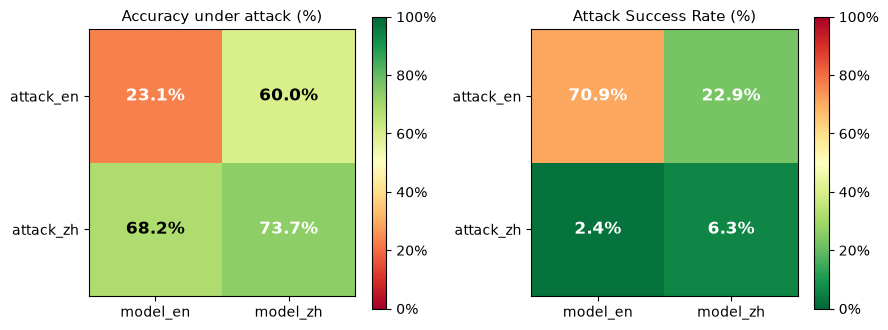

Saved -> results/accuracy_matrix.png


In [31]:
n = len(LANGS)
acc_matrix = np.zeros((n, n))
asr_matrix = np.zeros((n, n))
for i, al in enumerate(LANGS):
    for j, ml in enumerate(LANGS):
        p = preds_attacked[al][ml]
        acc_matrix[i, j] = (p == true).mean()
        asr_matrix[i, j] = (p == target).mean()

# Build display table including clean row
clean_row = np.array([clean_acc[ml] for ml in LANGS])
table_acc = np.vstack([clean_row, acc_matrix])
row_labels = ['clean (no attack)'] + [f'attack_{l}' for l in LANGS]
col_labels = [f'model_{l}' for l in LANGS]

print('Accuracy matrix (%):')
print(f'  {"":22s}', '  '.join(f'{c:>12s}' for c in col_labels))
for r, row in zip(row_labels, table_acc):
    print(f'  {r:22s}', '  '.join(f'{100*v:11.1f}%' for v in row))

table_asr = np.vstack([np.zeros(n), asr_matrix])
print('\nAttack Success Rate matrix (%):')
print(f'  {"":22s}', '  '.join(f'{c:>12s}' for c in col_labels))
for r, row in zip(row_labels, table_asr):
    print(f'  {r:22s}', '  '.join(f'{100*v:11.1f}%' for v in row))

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, mat, title in zip(
        axes,
        [acc_matrix, asr_matrix],
        ['Accuracy under attack (%)', 'Attack Success Rate (%)']):
    im = ax.imshow(mat * 100, vmin=0, vmax=100,
                   cmap='RdYlGn' if 'Accuracy' in title else 'RdYlGn_r')
    ax.set_xticks(range(n)); ax.set_xticklabels([f'model_{l}' for l in LANGS])
    ax.set_yticks(range(n)); ax.set_yticklabels([f'attack_{l}' for l in LANGS])
    ax.set_title(title, fontsize=11)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{100*mat[i,j]:.1f}%', ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if mat[i,j] < 0.3 or mat[i,j] > 0.7 else 'black')
    plt.colorbar(im, ax=ax, format='%.0f%%')
plt.tight_layout()
plt.savefig('results/accuracy_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/accuracy_matrix.png')


## 8. Grad-CAM heatmaps

Class Activation Maps (Grad-CAM on the ViT patch-embedding conv) for each model's **predicted class**.
Separate from the font-overlay sample grid — heatmap blended onto the image only.

Columns: **Clean** | **EN attack** | **ZH attack**.  
Within each cell: EN-model CAM (left) and ZH-model CAM (right).

In [ ]:
from matplotlib import cm

DISPLAY_SIZE = 224

def upscale_for_display(img):
    return img.resize((DISPLAY_SIZE, DISPLAY_SIZE), Image.NEAREST)

# Precompute text embeddings for all CIFAR-10 classes (one forward pass per model)
TEXT_EMB = {
    lang: models[lang].embed_texts(CLASSES[lang]).detach()
    for lang in LANGS
}

def _norm_cam(cam):
    cam = cam.relu() if isinstance(cam, torch.Tensor) else np.maximum(cam, 0)
    cam = cam.detach().cpu().numpy() if isinstance(cam, torch.Tensor) else cam
    cam = cam - cam.min()
    mx = cam.max()
    return cam / mx if mx > 0 else cam

def _cam_from_conv(act, grad):
    w = grad.mean(dim=(2, 3), keepdim=True)
    return _norm_cam((w * act).sum(dim=1).squeeze(0))

def gradcam_en(pil_img, target_idx):
    """Grad-CAM on OpenAI CLIP ViT-B/32 patch conv for one target class."""
    wrapper = models['en']
    acts = {}

    def hook(_m, _i, out):
        out.retain_grad()
        acts['v'] = out

    handle = wrapper.m.visual.conv1.register_forward_hook(hook)
    x = wrapper.pp(pil_img).unsqueeze(0).to(DEVICE)
    feat = wrapper.m.visual(x)
    img_feat = F.normalize(feat, dim=-1)
    score = (img_feat @ TEXT_EMB['en'][target_idx:target_idx + 1].T).squeeze()
    wrapper.m.zero_grad()
    score.backward()
    cam = _cam_from_conv(acts['v'].detach(), acts['v'].grad)
    handle.remove()
    return cam

def gradcam_zh(pil_img, target_idx):
    """Grad-CAM on Chinese CLIP ViT patch conv for one target class."""
    wrapper = models['zh']
    acts = {}
    patch = wrapper.m.vision_model.embeddings.patch_embedding

    def hook(_m, _i, out):
        out.retain_grad()
        acts['v'] = out

    handle = patch.register_forward_hook(hook)
    pv = wrapper.p(images=[pil_img], return_tensors='pt').pixel_values.to(DEVICE)
    out = wrapper.m.get_image_features(pixel_values=pv)
    img_feat = F.normalize(_clip_feat(out), dim=-1)
    score = (img_feat @ TEXT_EMB['zh'][target_idx:target_idx + 1].T).squeeze()
    wrapper.m.zero_grad()
    score.backward()
    cam = _cam_from_conv(acts['v'].detach(), acts['v'].grad)
    handle.remove()
    return cam

GRADCAM_FN = {'en': gradcam_en, 'zh': gradcam_zh}

def overlay_cam(pil_img, cam, alpha=0.50):
    """Resize CAM to image and blend with jet colormap."""
    disp = upscale_for_display(pil_img)
    h, w = disp.size[1], disp.size[0]
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
    heat = cm.jet(np.array(cam_img) / 255.0)[:, :, :3]
    base = np.array(disp).astype(np.float32) / 255.0
    blended = np.clip((1 - alpha) * base + alpha * heat, 0, 1)
    return Image.fromarray((blended * 255).astype(np.uint8))

def cam_for_model(model_lang, pil_img):
    pred = int(classify(models[model_lang], [pil_img], CLASSES[model_lang])[0])
    cam = GRADCAM_FN[model_lang](pil_img, pred)
    return overlay_cam(pil_img, cam), pred

# One image per class (same indices as sample viz)
cam_select = [(c, int(np.where(true == c)[0][0])) for c in range(10)]
cond_specs = [
    ('Clean',     lambda pos: clean[pos]),
    ('EN attack', lambda pos: draw_word(clean[pos], CLASSES['en'][target[pos]], where='bottom')),
    ('ZH attack', lambda pos: draw_word(clean[pos], CLASSES['zh'][target[pos]], where='bottom')),
]

fig, axes = plt.subplots(10, 3, figsize=(10, 34))
fig.suptitle(
    'Grad-CAM (predicted class) — EN model (left) vs ZH model (right)
'
    'ViT patch-embedding layer; heatmap only, no font labels',
    fontsize=12, y=1.005)

for ax, title in zip(axes[0], [s[0] for s in cond_specs]):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

for row_i, (c, pos) in enumerate(cam_select):
    for col_i, (_, img_fn) in enumerate(cond_specs):
        src_img = img_fn(pos)
        panels = []
        for ml in LANGS:
            panel, pred = cam_for_model(ml, src_img)
            panels.append((panel, ml, pred))
        combined = Image.new('RGB', (DISPLAY_SIZE * 2, DISPLAY_SIZE))
        combined.paste(panels[0][0], (0, 0))
        combined.paste(panels[1][0], (DISPLAY_SIZE, 0))
        ax = axes[row_i, col_i]
        ax.imshow(combined, interpolation='nearest')
        ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(CLASSES['en'][c], fontsize=9, rotation=0, labelpad=42, va='center')
        caption = '  |  '.join(
            f"{ml.upper()}: {CLASSES['en'][pred][:5]}" for panel, ml, pred in panels)
        ax.set_xlabel(caption, fontsize=6.5, labelpad=2)

plt.tight_layout()
plt.savefig('results/gradcam_heatmaps.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> results/gradcam_heatmaps.png')


## 9. Sample visualisation — clean | EN-attacked | ZH-attacked

One row per CIFAR-10 class. Three columns:
- **Clean** — original image
- **EN attack** — adversarial English word overlaid
- **ZH attack** — adversarial Chinese word overlaid

Below each image: EN model and ZH model predictions (green = correct, red = fooled).

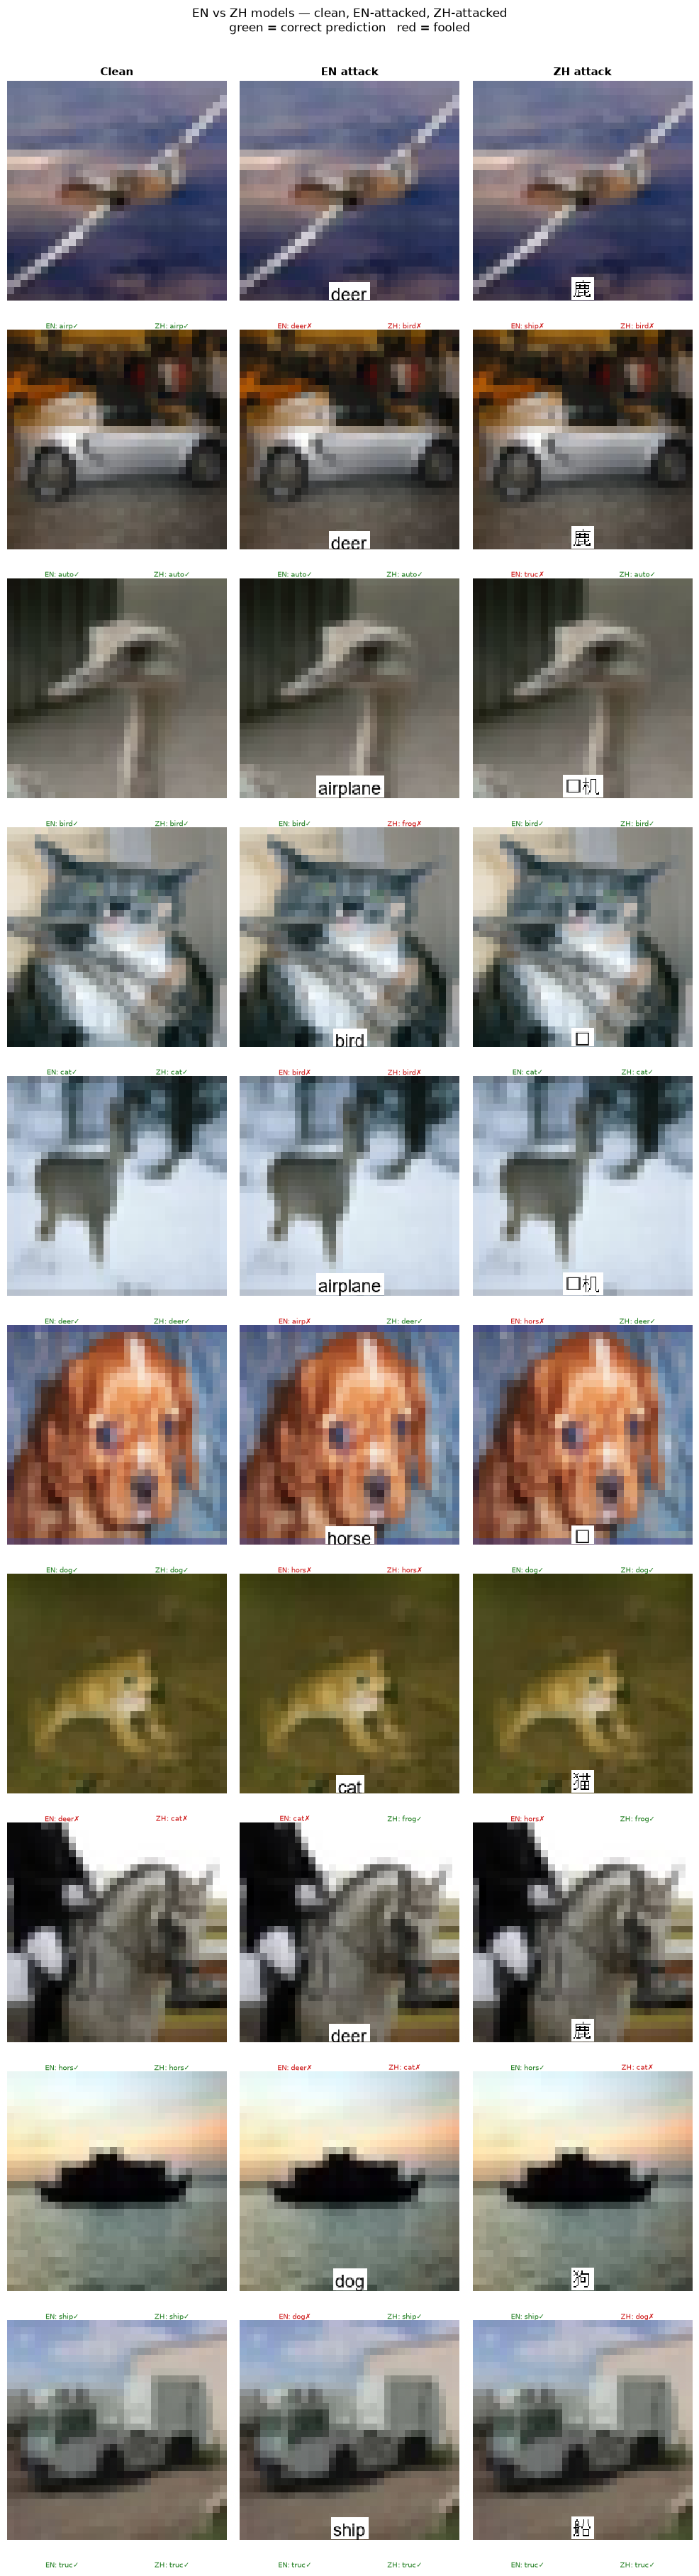

Saved -> results/sample_viz.png


In [34]:
def pred_labels_2(ax, preds_by_model, array_idx, true_class, y=-0.10):
    """Coloured per-model text for EN and ZH only."""
    for j, ml in enumerate(LANGS):
        pred = int(preds_by_model[ml][array_idx])
        ok   = (pred == true_class)
        col  = '#1a7a1a' if ok else '#cc1111'
        sym  = '\u2713' if ok else '\u2717'
        ax.text((j + 0.5) / len(LANGS), y,
                f"{ml.upper()}: {CLASSES['en'][pred][:4]}{sym}",
                transform=ax.transAxes, fontsize=7, color=col,
                ha='center', va='top', clip_on=False)

DISPLAY_SIZE = 224

def upscale_for_display(img):
    return img.resize((DISPLAY_SIZE, DISPLAY_SIZE), Image.NEAREST)

def draw_word_display(img, word, where='bottom'):
    """Upscale first so overlay text stays small relative to the image."""
    return draw_word(upscale_for_display(img), word, where=where)

# One image per class
select = [(c, int(np.where(true == c)[0][0])) for c in range(10)]

fig, axes = plt.subplots(10, 3, figsize=(10, 36))
fig.suptitle(
    'EN vs ZH models — clean, EN-attacked, ZH-attacked\n'
    'green = correct prediction   red = fooled',
    fontsize=12, y=1.005)

col_titles = ['Clean', 'EN attack', 'ZH attack']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=11, fontweight='bold', pad=6)

for row_i, (c, pos) in enumerate(select):
    true_class = int(true[pos])
    clean_disp = upscale_for_display(clean[pos])
    atk_en_disp = draw_word_display(clean[pos], CLASSES['en'][target[pos]], where='bottom')
    atk_zh_disp = draw_word_display(clean[pos], CLASSES['zh'][target[pos]], where='bottom')

    images = [clean_disp, atk_en_disp, atk_zh_disp]
    sources = [
        {ml: clean_preds[ml]          for ml in LANGS},
        {ml: preds_attacked['en'][ml] for ml in LANGS},
        {ml: preds_attacked['zh'][ml] for ml in LANGS},
    ]

    for col_i, (img, src) in enumerate(zip(images, sources)):
        ax = axes[row_i, col_i]
        ax.imshow(img, interpolation='nearest')
        ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(f"{CLASSES['en'][c]}", fontsize=9,
                          rotation=0, labelpad=50, va='center')
        pred_labels_2(ax, src, pos, true_class)

plt.tight_layout()
plt.savefig('results/sample_viz.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> results/sample_viz.png')


## 10. Disagreement detector — AUC analysis

Detection signal: number of unique predictions across EN and ZH models.
Clean images usually agree (score = 1); attacked images may disagree (score = 2).
AUC measures how well disagreement separates attacked from clean images.

In [33]:
def disagreement_score(preds_mat):
    """Count unique predictions per image across all models. Shape: (n_images,)."""
    return np.array([len(set(preds_mat[:, i])) for i in range(preds_mat.shape[1])])

def roc_auc(pos_scores, neg_scores):
    """Standard AUC: P(pos>neg) + 0.5*P(pos==neg). Ties are half-credit."""
    gt  = (pos_scores[:, None] >  neg_scores[None, :]).astype(float)
    tie = (pos_scores[:, None] == neg_scores[None, :]).astype(float)
    return float(np.mean(gt + 0.5 * tie))

preds_clean_mat = np.stack([clean_preds[l] for l in LANGS])   # (2, N)
scores_clean    = disagreement_score(preds_clean_mat)
agree_clean     = float((scores_clean == 1).mean())

print('=== Disagreement detector — EN vs ZH ===\n')
print(f'Clean all-agree rate: {100*agree_clean:.1f}%\n')
print(f"{'Attack':>8}  {'All-agree':>10}  {'AUC':>8}")
print('-' * 32)

detector_results = {}
for attack_lang in LANGS:
    preds_atk_mat   = np.stack([preds_attacked[attack_lang][l] for l in LANGS])
    scores_attacked = disagreement_score(preds_atk_mat)
    auc_val         = roc_auc(scores_attacked, scores_clean)
    agree_atk       = float((scores_attacked == 1).mean())

    print(f"  {attack_lang.upper():>4}    {100*agree_atk:6.1f}%    {auc_val:.4f}")

    detector_results[attack_lang] = {
        'agree_attacked':      agree_atk,
        'auc':                 auc_val,
        'score_dist_attacked': {str(s): int((scores_attacked == s).sum()) for s in range(1, 3)},
    }

print()
print('Score distribution for clean images:')
for s in range(1, 3):
    n = (scores_clean == s).sum()
    print(f'  score={s}: {n:4d} ({100*n/len(scores_clean):.0f}%)')


Saved -> results/confusion_results.json


## 11. Save results

In [ ]:
results = {
    'langs':      LANGS,
    'classes':    CLASSES,
    'n_images':   len(idx),
    'sample_idx': idx,
    'clean_acc':  {l: float(clean_acc[l]) for l in LANGS},
    'acc_matrix': acc_matrix.tolist(),
    'asr_matrix': asr_matrix.tolist(),
    'detector': {
        'agree_clean':      agree_clean,
        'score_dist_clean': {str(s): int((scores_clean == s).sum()) for s in range(1, 3)},
        'by_attack_lang':   detector_results,
    },
}
with open('results/confusion_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print('Saved -> results/confusion_results.json')